# Notebook 9 — Decision Trees
### Sprint 7 | Machine Learning Fundamentals for AI/ML Engineers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])
df_encoded = df.copy()
for col in encode_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (5634, 19) | Test: (1409, 19)


/tmp/ipykernel_709/906927670.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])


---
## Algorithm Documentation

### What is the algorithm?
A tree of yes/no questions about feature values, learned automatically from data, that
splits the data step by step until reaching a final prediction.

### Problem Type
Both **Classification** and **Regression** — used here for classification.

### Concept
- **Root Node**: the very first split, covering all data.
- **Internal Node**: any subsequent split.
- **Leaf Node**: a terminal node with no further splits — holds the final prediction.
- **Splitting**: at each node, the algorithm tries every possible feature/threshold and
  picks the one that best separates the classes.

### Mathematical Intuition — Gini Impurity & Entropy/Information Gain
**Gini Impurity**: $Gini = 1 - \sum p_i^2$, where $p_i$ is the proportion of class $i$
in a node. A pure node (all one class) has Gini = 0; a 50/50 split has the maximum Gini
(0.5 for binary). **Entropy**: $-\sum p_i \log_2(p_i)$, a similar impurity measure from
information theory. **Information Gain** is the reduction in entropy/Gini achieved by a
split — the tree greedily picks, at every node, the split that maximizes this gain.

### Example


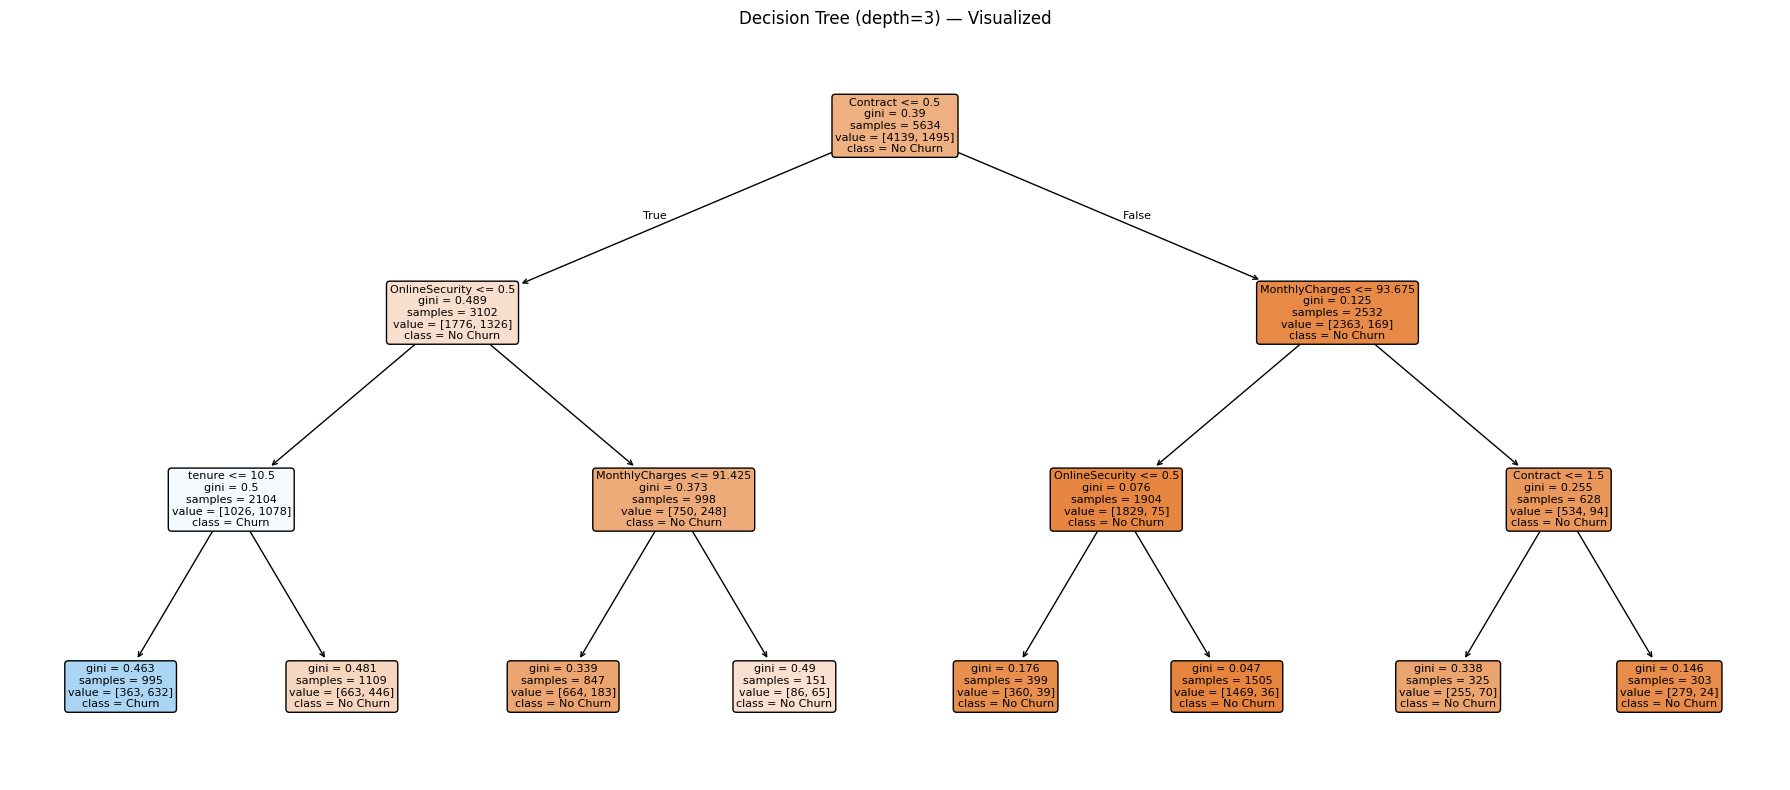

In [2]:
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_small.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(tree_small, feature_names=X.columns, class_names=['No Churn', 'Churn'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree (depth=3) — Visualized')
plt.tight_layout()
plt.show()


### How the Tree Arrives at a Prediction
Starting at the root, a new customer's feature values are compared against each node's
threshold, sending them left or right, repeating down to a leaf — the leaf's majority
class (or class probability) becomes the prediction. This is fully traceable: unlike
Logistic Regression's coefficients (a global summary) or KNN's distance calculation, a
Decision Tree's reasoning for any SPECIFIC prediction can be read off as a literal path
through the tree.

### Implementation


In [3]:
root_feature = X.columns[tree_small.tree_.feature[0]]
root_threshold = tree_small.tree_.threshold[0]
print(f"Root node splits on: '{root_feature}' <= {root_threshold:.2f}")
print("This confirms the tree independently 'discovered' one of this sprint's most consistently")
print("important features as worth splitting on FIRST, before any other feature.")


Root node splits on: 'Contract' <= 0.50
This confirms the tree independently 'discovered' one of this sprint's most consistently
important features as worth splitting on FIRST, before any other feature.


### Parameters — Tree Depth & Overfitting


In [4]:
depths = [1, 2, 3, 5, 10, None]
results = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    results.append({
        'max_depth': d if d else 'Unlimited',
        'train_accuracy': tree.score(X_train, y_train),
        'test_accuracy': tree.score(X_test, y_test)
    })
results_df = pd.DataFrame(results)
print(results_df.round(4))


   max_depth  train_accuracy  test_accuracy
0          1          0.7346         0.7346
1          2          0.7439         0.7367
2          3          0.7824         0.7828
3          5          0.8044         0.7850
4         10          0.8717         0.7743
5  Unlimited          0.9980         0.7289


### Result & Interpretation


In [5]:
best_row = results_df.loc[results_df['test_accuracy'].idxmax()]
print(f"Best test performance at max_depth={best_row['max_depth']} (test accuracy: {best_row['test_accuracy']:.4f})")
print(f"Unlimited-depth train accuracy: {results_df.iloc[-1]['train_accuracy']:.4f} vs test: {results_df.iloc[-1]['test_accuracy']:.4f}")
print(f"Gap (unlimited depth): {results_df.iloc[-1]['train_accuracy'] - results_df.iloc[-1]['test_accuracy']:.4f}")


Best test performance at max_depth=5 (test accuracy: 0.7850)
Unlimited-depth train accuracy: 0.9980 vs test: 0.7289
Gap (unlimited depth): 0.2692


**Interpretation:** The unlimited-depth tree shows the largest train-test gap in
the table — textbook overfitting, since an unconstrained tree can keep splitting until
every training leaf is pure (even down to single, noisy examples), a pattern that
doesn't generalize. This is a direct, hands-on illustration of why `max_depth` (and
other constraints, below) matter, previewing Notebook 16's full bias-variance treatment.

### Pruning


In [6]:
# Cost-complexity pruning: find the alpha values available for this tree
full_tree = DecisionTreeClassifier(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
print(f"Number of candidate pruning alphas found: {len(path.ccp_alphas)}")
print(f"Smallest alphas (least pruning): {path.ccp_alphas[:3].round(6)}")
print(f"Largest alphas (most pruning): {path.ccp_alphas[-3:].round(4)}")


Number of candidate pruning alphas found: 450
Smallest alphas (least pruning): [0.0e+00 3.0e-05 3.8e-05]
Largest alphas (most pruning): [0.0101 0.0167 0.0644]


**Understand:** Pruning removes branches that provide little real predictive
power, AFTER the tree is fully grown — `ccp_alpha` controls how aggressively branches
are cut back. This is an alternative (or complement) to limiting `max_depth` upfront.


### Advantages
- Highly interpretable — a specific prediction's exact reasoning can be traced.
- No feature scaling required (unlike KNN, Notebook 7) — splits are threshold-based,
  not distance-based.
- Naturally handles both numeric and (label-encoded) categorical features.

### Limitations
- Prone to overfitting without depth/leaf constraints (demonstrated directly above).
- Unstable — a small change in training data can produce a very different tree
  structure (motivating Random Forest's averaging approach, Notebook 10).
- Greedy splitting (choosing the best split at each step individually) doesn't
  guarantee the globally optimal tree.

### When to Use
When interpretability is a priority, when features are on very different scales
(avoiding a scaling step), or as a foundation for ensemble methods (Notebook 10).

### When Not to Use
When stability across small data changes matters, or when a single tree's accuracy
ceiling isn't sufficient — an ensemble (Random Forest, Notebook 10) will almost always
outperform a single tree.


---
## Summary

| max_depth | Train Acc | Test Acc | Verdict |
|---|---|---|---|
| 1-2 | Lower | Lower | Likely underfitting |
| 3-5 | Moderate | Best/near-best | Reasonable balance |
| Unlimited | Very high | Lower than moderate depths | Overfitting |

**Next notebook:** `09_Random_Forest.ipynb` — addressing this single tree's instability
and overfitting risk by combining many trees.
